In [1]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn import tree as sk_tree # We'll use this at the end to visualize our result

In [2]:
# --- 1. Define the Node Class ---
# This class stores the data for each "decision" point (node) in our tree.
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        # 'feature' is the index (column) of the feature we split on.
        self.feature = feature
        # 'threshold' is the value we use for the split (e.g., petal_width < 0.8).
        self.threshold = threshold
        # 'left' is the Node for data that passes the test (e.g., < threshold).
        self.left = left
        # 'right' is the Node for data that fails the test (e.g., >= threshold).
        self.right = right
        # 'value' is the class label (e.g., 'setosa') if this is a LEAF node (an endpoint).
        self.value = value

    # Helper function to check if this node is a leaf node.
    def is_leaf_node(self):
        return self.value is not None

In [3]:
# --- 2. Define the DecisionTree Class ---
# This class will hold the main logic for building and predicting.
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100):
        # 'min_samples_split' stops splitting if a node has fewer samples than this.
        self.min_samples_split = min_samples_split
        # 'max_depth' sets the maximum number of "questions" in a row.
        self.max_depth = max_depth
        # 'root' will store the very first Node of our trained tree.
        self.root = None

    # --- 2a. Gini Impurity (Our "Cost Function") ---
    # This measures how "mixed" a set of labels is. 
    # A Gini of 0 is perfectly "pure" (all samples have the same label).
    def _gini(self, y):
        # Count how many times each label appears.
        _, counts = np.unique(y, return_counts=True)
        # Calculate the probability of each label.
        probabilities = counts / len(y)
        # Gini formula: 1 - (sum of (probabilities^2))
        gini = 1 - np.sum([p**2 for p in probabilities])
        return gini

    # --- 2b. Find the Best Split ---
    # This function iterates through all features and all thresholds to find
    # the split that gives the HIGHEST Information Gain (lowest combined Gini).
    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        
        # Calculate the Gini of the current (parent) node.
        parent_gini = self._gini(y)
        
        # We'll store the best split we find here.
        best_gain = -1
        best_feature_idx, best_threshold = None, None

        # Loop over all features (columns).
        for feature_idx in range(n_features):
            # Get all unique values for this feature to use as potential thresholds.
            thresholds = np.unique(X[:, feature_idx])
            
            # Loop over all unique values (thresholds).
            for threshold in thresholds:
                # --- Split the data ---
                left_indices = np.where(X[:, feature_idx] <= threshold)[0]
                right_indices = np.where(X[:, feature_idx] > threshold)[0]

                # Skip this split if it doesn't create two children.
                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                # --- Calculate weighted average Gini of children ---
                n_left, n_right = len(left_indices), len(right_indices)
                gini_left = self._gini(y[left_indices])
                gini_right = self._gini(y[right_indices])
                
                # Weighted average based on sample size.
                weighted_gini = (n_left / n_samples) * gini_left + (n_right / n_samples) * gini_right
                
                # --- Calculate Information Gain ---
                # Info Gain is how much the Gini impurity was reduced.
                information_gain = parent_gini - weighted_gini
                
                # If this split is the best one we've seen, save it.
                if information_gain > best_gain:
                    best_gain = information_gain
                    best_feature_idx = feature_idx
                    best_threshold = threshold
        
        return best_feature_idx, best_threshold

    # --- 2c. Build the Tree (The Recursive Part) ---
    # This is the core function. It calls itself to build the left and right branches.
    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # --- Check for "stopping conditions" (base cases for recursion) ---
        
        # 1. Is the max depth reached?
        # 2. Are there too few samples to split?
        # 3. Is this node already "pure" (all labels are the same)?
        if (depth >= self.max_depth or 
            n_labels == 1 or 
            n_samples < self.min_samples_split):
            
            # If any condition is met, this becomes a LEAF node.
            # We "predict" the most common label in this group.
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        # --- If we don't stop, we split ---
        
        # Find the best feature and threshold to split on.
        best_feature_idx, best_threshold = self._best_split(X, y)
        
        # If _best_split returns None (e.g., no way to split further), make a leaf.
        if best_feature_idx is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        # Split the data into left and right branches based on the best split.
        left_indices = np.where(X[:, best_feature_idx] <= best_threshold)[0]
        right_indices = np.where(X[:, best_feature_idx] > best_threshold)[0]
        
        X_left, y_left = X[left_indices, :], y[left_indices]
        X_right, y_right = X[right_indices, :], y[right_indices]

        # --- THIS IS THE RECURSION ---
        # We call _build_tree for the left child...
        left_child = self._build_tree(X_left, y_left, depth + 1)
        # ...and we call _build_tree for the right child.
        right_child = self._build_tree(X_right, y_right, depth + 1)
        
        # Create a new Node that holds this split information and its children.
        return Node(best_feature_idx, best_threshold, left_child, right_child)

    # --- 2d. Fit (Train) the Model ---
    # This is the public function a user calls to start the training.
    def fit(self, X, y):
        # It just calls _build_tree and saves the result as the 'root' of our tree.
        self.root = self._build_tree(X, y)

    # --- 2e. Predict (Make Predictions) ---
    # This is the public function to predict on new data.
    def predict(self, X):
        # We call our helper function _traverse_tree for each sample (row) in X.
        return np.array([self._traverse_tree(x, self.root) for x in X])

    # This helper function "walks" down the tree for a *single* sample.
    def _traverse_tree(self, x, node):
        # Base case: If we're at a leaf, return its value.
        if node.is_leaf_node():
            return node.value

        # If we're not at a leaf, we ask the node's "question".
        if x[node.feature] <= node.threshold:
            # If TRUE, go left.
            return self._traverse_tree(x, node.left)
        else:
            # If FALSE, go right.
            return self._traverse_tree(x, node.right)

In [4]:
# --- 3. Run the Model ---
print("--- Loading Data ---")
# Load the Iris dataset.
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Features: {feature_names}")
print(f"Targets: {target_names}")

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

print("\n--- Training Model ---")
# Create our tree with a max depth of 3 to keep it simple.
clf = DecisionTree(max_depth=3)
# Train the model.
clf.fit(X_train, y_train)
print("Model training complete.")

print("\n--- Evaluating Model ---")
# Make predictions on the test data.
y_pred = clf.predict(X_test)

# Calculate accuracy.
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

--- Loading Data ---
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Targets: ['setosa' 'versicolor' 'virginica']
Train samples: 120, Test samples: 30

--- Training Model ---
Model training complete.

--- Evaluating Model ---
Accuracy: 96.67%



--- Visualizing Equivalent Scikit-learn Tree ---
Saved tree visualization to 'decision_tree_visualization.png'


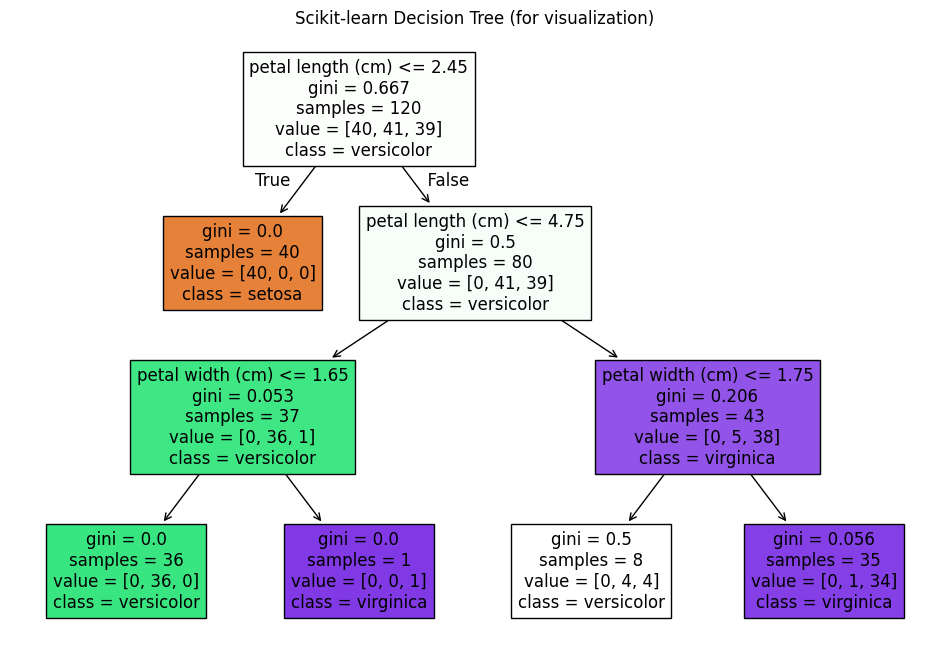

In [5]:
# --- 4. Bonus: Visualize the Scikit-learn Version ---
# We can't easily plot our "from-scratch" tree, but we can
# train a scikit-learn tree on the *same data* to visualize what
# our tree *should* look like.
print("\n--- Visualizing Equivalent Scikit-learn Tree ---")
clf_sklearn = sk_tree.DecisionTreeClassifier(max_depth=3, random_state=42)
clf_sklearn.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
sk_tree.plot_tree(clf_sklearn, 
                  feature_names=feature_names, 
                  class_names=target_names, 
                  filled=True)
plt.title("Scikit-learn Decision Tree (for visualization)")
plt.savefig('decision_tree_visualization.png')
print("Saved tree visualization to 'decision_tree_visualization.png'")